In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

precip_data = pd.read_csv('combined_ENSO_highresprecip.csv')
df = pd.read_csv('DATABASE3.csv')

df = df[df['YEAR'] != 2021]
df = df[df['YEAR'] != 2020]



In [2]:
df

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value
0,1,89,2225,1,8,1975,13,20,2,1,4,-0.45
1,1,69,2961,1,4,1975,1,15,2,1,7,-0.45
2,1,101,2130,1,3,1975,17,44,2,1,6,-0.45
3,1,117,0,1,10,1975,15,20,2,1,6,-0.45
4,1,83,120,1,8,1975,14,37,2,1,4,-0.45
...,...,...,...,...,...,...,...,...,...,...,...,...
194050,34,17,1520,12,11,2019,2,27,12,1,4,0.52
194051,42,21,8240,12,13,2019,9,48,12,1,6,0.52
194052,42,83,0,12,2,2019,13,52,12,1,2,0.52
194053,42,35,0,12,1,2019,11,26,12,1,1,0.52


In [5]:

crash_monthly = df.groupby(['YEAR', 'MONTH']).size().reset_index(name='CRASH_COUNT')

# Get monthly mean by averaging for each month across all years)
monthly_means = crash_monthly.groupby('MONTH')['CRASH_COUNT'].mean().reset_index(name='MONTHLY_MEAN')


crash_anomalies = crash_monthly.merge(monthly_means, on='MONTH')
crash_anomalies['CRASH_ANOMALY'] = crash_anomalies['CRASH_COUNT'] - crash_anomalies['MONTHLY_MEAN']

anomaly_table = crash_anomalies.pivot(index='YEAR', columns='MONTH', values='CRASH_ANOMALY')


print(anomaly_table)

MONTH          1           2           3           4           5           6   \
YEAR                                                                            
1975    47.222222   64.666667   67.022222   -3.933333   51.244444   38.266667   
1976  -129.777778  -99.333333  -32.977778  -51.933333  120.244444   51.266667   
1977   -85.777778 -137.333333   94.022222    0.066667  -74.755556   44.266667   
1978    17.222222  -75.333333   49.022222   25.066667  129.244444   -0.733333   
1979   218.222222  113.666667  132.022222  173.066667  122.244444    1.266667   
1980   208.222222  148.666667  194.022222   76.066667   80.244444  -12.733333   
1981  -126.777778  132.666667  -28.977778   34.066667  100.244444   98.266667   
1982   105.222222   60.666667   89.022222   44.066667   56.244444  145.266667   
1983    30.222222   48.666667  199.022222  222.066667  106.244444   45.266667   
1984   -36.777778   77.666667   67.022222  130.066667   80.244444   -7.733333   
1985   100.222222   63.66666

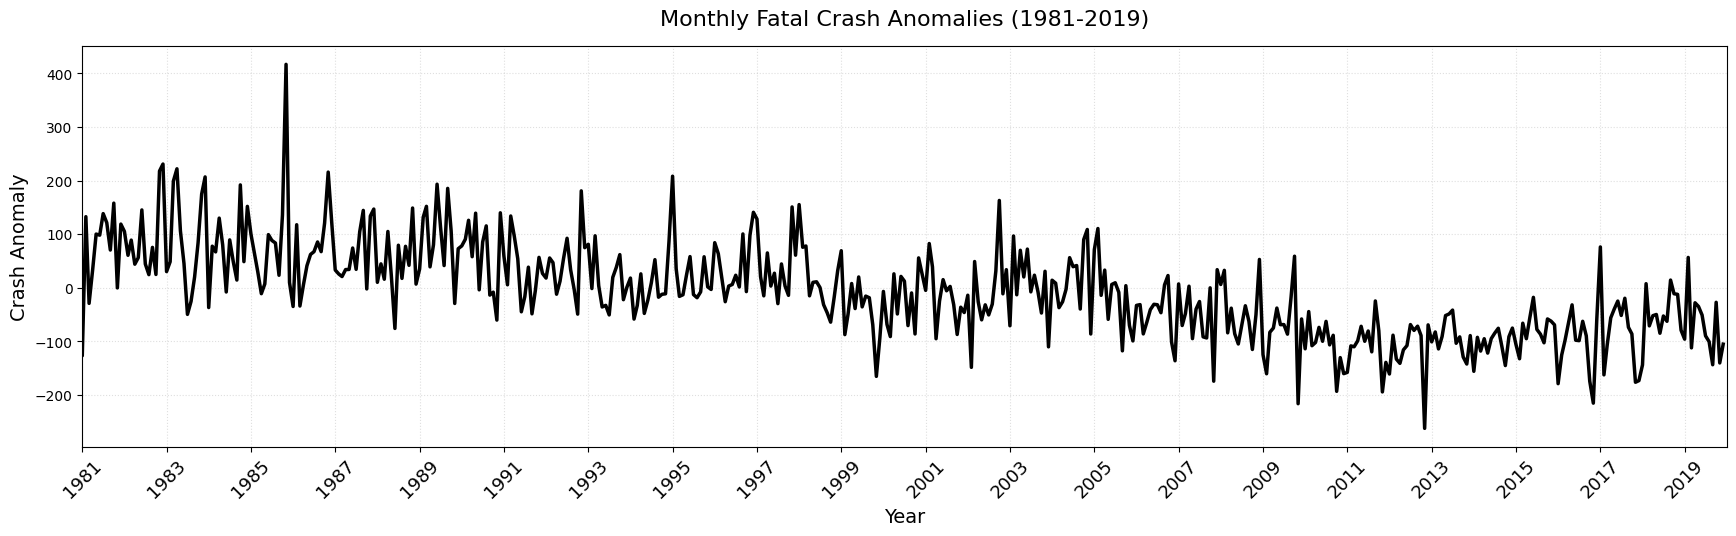

In [4]:

crash_anomalies['DATE'] = pd.to_datetime(crash_anomalies['YEAR'].astype(str) + '-' + crash_anomalies['MONTH'].astype(str))

fig, ax = plt.subplots(figsize=(18, 6))
font_size = 14


ax.plot(crash_anomalies['DATE'], crash_anomalies['CRASH_ANOMALY'], 
        color='black', linewidth=2.5, label='Crash Anomaly')

ax.set_title('Monthly Fatal Crash Anomalies (1981-2019)', fontsize=font_size+2, pad=15)
ax.set_ylabel('Crash Anomaly', fontsize=font_size)
ax.grid(True, linestyle=':', alpha=0.4)


ax.set_xlim(pd.to_datetime('1981-01-01'), pd.to_datetime('2019-12-31'))


years = pd.date_range(start='1981-01-01', end='2019-12-31', freq='2AS-JAN')
ax.set_xticks(years)
ax.set_xticklabels([y.year for y in years], rotation=45, fontsize=font_size-1)
ax.set_xlabel('Year', fontsize=font_size)

plt.tight_layout(pad=3.0)
plt.savefig('Crash_Anomalies_Only.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()